In [1]:
import pandas as pd

matches = pd.read_csv(r"C:\Data\matches.csv")
deliveries = pd.read_csv(r"C:\Data\deliveries.csv")

matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


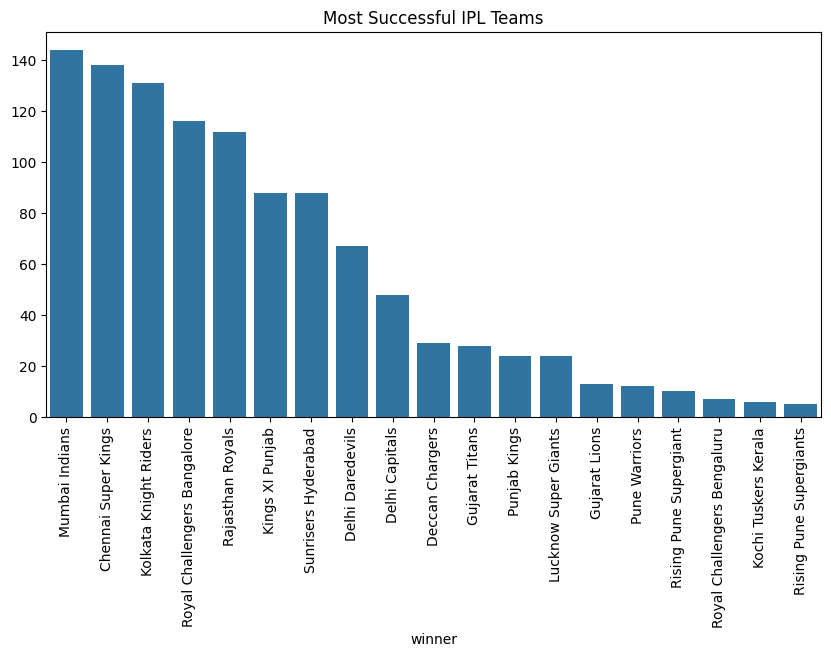

In [2]:
wins = matches['winner'].value_counts()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x=wins.index, y=wins.values)
plt.xticks(rotation=90)
plt.title("Most Successful IPL Teams")
plt.show()

In [3]:
toss_win = matches[matches['toss_winner'] == matches['winner']]

print("Toss Win Match Win %:",
      (len(toss_win) / len(matches)) * 100)

Toss Win Match Win %: 50.593607305936075


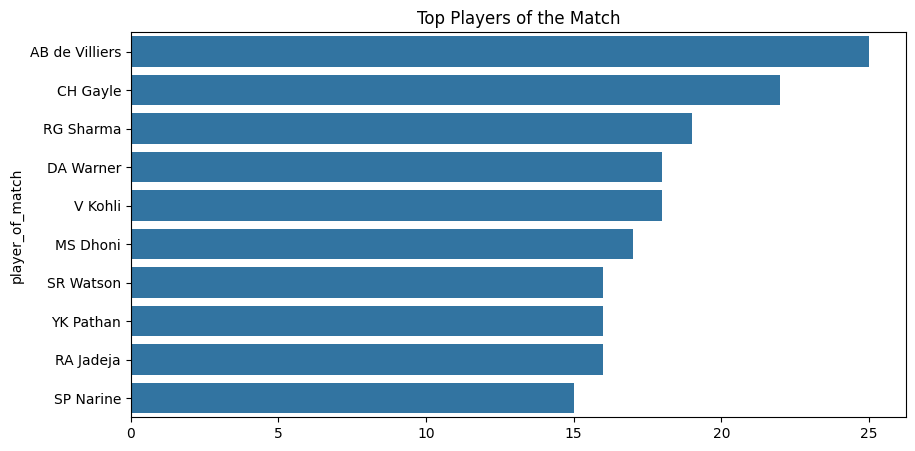

In [4]:
top_players = matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_players.values, y=top_players.index)
plt.title("Top Players of the Match")
plt.show()

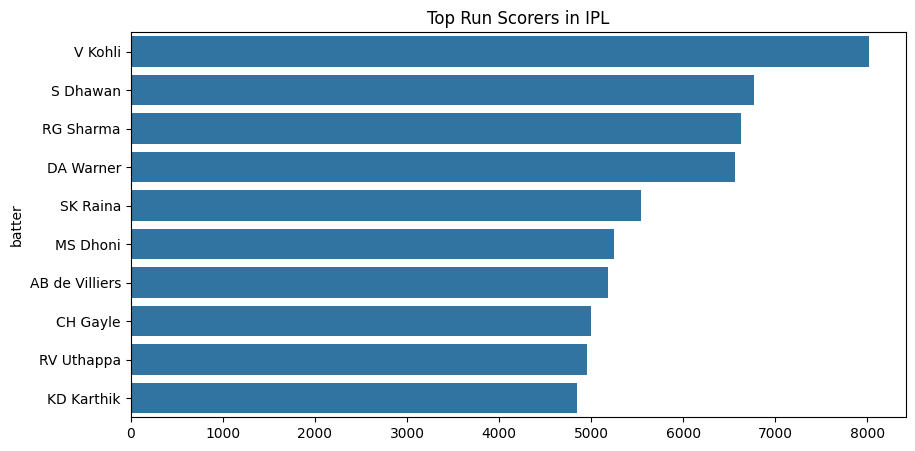

In [12]:
top_batsman = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_batsman.values, y=top_batsman.index)
plt.title("Top Run Scorers in IPL")
plt.show()

In [11]:
print(deliveries.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')


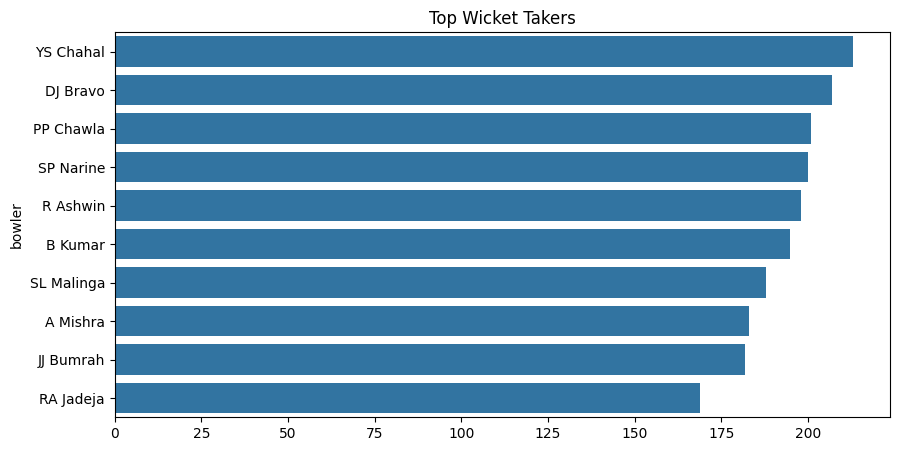

In [13]:
deliveries['is_wicket'] = deliveries['dismissal_kind'].notnull()

top_bowler = deliveries.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_bowler.values, y=top_bowler.index)
plt.title("Top Wicket Takers")
plt.show()